# Eindopdracht Data – Machine Learning voor een businessprobleem

In deze eindopdracht werk je als groep aan een zelfbedachte businesscase waarin je een **regressie- of classificatieprobleem** oplost met machine learning in Python.

Jullie doorlopen het hele proces: van businessprobleem naar data, datakwaliteit, voorbereiding, modeltraining, evaluatie en de vertaling van de resultaten naar implicaties voor de businesscase.

Gebruik in dit notebook **Markdown** om uit te leggen wat jullie doen, waarom jullie keuzes maken en wat de resultaten betekenen. Het notebook moet zelfstandig te begrijpen zijn.

> **Belangrijk:** een notebook dat niet uitvoerbaar is, leidt tot een onvoldoende. Controleer vóór het inleveren of alle cellen in de juiste volgorde kunnen worden uitgevoerd en of de benodigde output zichtbaar is.

## Groepsleden

Vul hieronder de namen en studentennummers van alle groepsleden in.

- Naam – studentnummer
- Naam – studentnummer
- Naam – studentnummer

## 1. Businesscase en probleemformulering

Beschrijf jullie zelfbedachte casus. Zorg dat duidelijk wordt:

- Wat is de organisatie of context?
- Wat is het concrete businessprobleem?
- Waarom is dit probleem relevant?
- Gaat het om een **regressieprobleem** of een **classificatieprobleem**? En waarom?
- Welke variabele willen jullie voorspellen?
- Hoe zou de uitkomst van het model in de praktijk gebruikt kunnen worden?

Leg expliciet de relatie uit tussen het businessprobleem en het machine-learningprobleem.

De Banjul Cacao Factory (BCF) is een cacaofabriek in Gambia die grotendeels werkt met verouderde machines en handmatige productieprocessen. Dit draagt bij aan een vergroot risico op storingen en defecte machines, waardoor de productie (tijdelijk) stil komt te liggen. Daar komt bovenop dat de fabriek te maken heeft met een instabiele stroomvoorziening. Stroomuitval komt regelmatig voor en kan ervoor zorgen dat de productie meerdere uren stil komt te liggen. Hiervoor maakt BCF gebruik van dieselgeneratoren, maar deze brengen hoge energiekosten met zich mee en zetten daardoor de financiële positie van het bedrijf onder druk.

Binnen deze context richten wij ons op het probleem van het onvoorspelbare defectpercentage. Hiervoor heeft BCF nog geen voorspellende analyses, waardoor zij niet tijdig kan anticiperen op een hoog percentage defecte producten (welk percentage van de geproduceerde cacao niet aan de kwaliteitseisen voldoet) en onnodige verspilling het gevolg is.

Binnen dit datavraagstuk zal via Python-programmeren het defectpercentage (target) worden voorspeld aan de hand van de volgende features: verlooppercentage (%), medewerkerstevredenheid (1-50), trainingstijden (uren) en productie (kg). Hierbij gaat het om een regressieprobleem, omdat de variabele die we willen voorspellen een continue numerieke waarde is. Het defectpercentage vormt daarmee de targetvariabele van het model.

De uitkomst van het model kan vervolgens in de praktijk worden gebruikt om vroegtijdig bij te sturen op personeelsbeleid. Het model kan vooraf inschatten in welke periodes het defectpercentage zal oplopen en op die manier kunnen vroegtijdig trainingen worden ingepland en tevredenheidsproblemen worden aangepakt. Daarnaast kunnen de schaarse middelen die BCF beschikbaar heeft voor trainingen met behulp van het probleem zo efficiënt mogelijk worden ingezet.

De features medewerkerstevredenheid en trainingstijd zijn geselecteerd op basis van correlatie. De features energieverbruik en productie hebben geen sterke correlatie, maar worden toch gebruikt omdat veel productie samengaat met een hoge werkdruk en meer kans op fouten. Verlooppercentage heeft invloed op de ervaring van de medewerkers en daarmee op de hoeveelheid foute productie en zal dus ook als feature worden meegenomen.

De voorspelling zelf voorkomt niet rechtstreeks een hoog defectpercentage, maar geeft BCF wel de informatie om eerder maatregelen te nemen en daarmee het defectpercentage te verkleinen.

## 2. Dataset inladen en eerste verkenning

Laad de gegenereerde dataset in met Python.

Voer daarna een eerste verkenning uit. Laat minimaal zien:

- welke kolommen aanwezig zijn;
- hoeveel rijen en kolommen de dataset bevat;
- welke datatypes voorkomen;
- een eerste indruk van de waarden in de dataset.

### 2.1 Libraries importeren

In deze stap worden de libraries geïmporteerd die nodig zijn voor het inladen, bewerken, modelleren, eavlueren en visualiseren van de data.

In [22]:
# Importeer hier de benodigde libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

Met deze libraries beschikbaar kan in de volgende stappen de dataset worden ingeladen en verder worden onderzocht.


### 2.2 Datasets inladen

Vervolgens worden alle CSV-bestanden uit de map data ingelezen. Met een loop wordt voor elk bestand automatisch een dataframe aangemaakt en opgeslagen onder een duidelijke naam, zodat alle datasets van BCF eenvoudig en overzichtelijk beschikbaar zijn voor verdere analyse.


In [23]:
# Laad hier de dataset in
data_dir = Path("data")

# Lees alle csv-bestanden in de data directory in en maak er een dataframe van.
dataframes = {}
for file in data_dir.glob("*.csv"):
    naam = re.sub(r"\W", "_", file.stem)   
    if naam[0].isdigit():
        naam = f"_{naam}"

    df = pd.read_csv(file)
    dataframes[naam] = df
    globals()[naam] = df  

print(list(dataframes.keys()))

['bcf_boeren_data_adjusted', 'bcf_financieel_overzicht_adjusted', 'bcf_hr_training_varied', 'bcf_kwaliteit_klanttevredenheid_varied', 'bcf_omgeving_data_adjusted', 'bcf_productie_duurzaamheid_adjusted']


Alle zes datasets van BCF zijn succesvol ingeladen: boerendata, financieel overzicht, hr/training, kwaliteit & klanttevredenheid, omgevingsdata en productie & duurzaamheid. Deze dataframes vormen de basis voor de eerste verkenning en de latere datakwaliteitscontrole.


### 2.3 Aanwezige kolommen, aantal rijen & datatypes

Hieronder wordt een loop geschreven om voor elk dataframe het aantal rijen, kolommen en de datatypes te laten zien.

In [24]:
# Loop om aantal rijen, aantal kolommen en datatypes van alle dataframes te laten zien.
for naam, df in dataframes.items():
    print(f"===== {naam} =====")
    print(f"Aantal rijen: {df.shape[0]}")
    print(f"Aantal kolommen: {df.shape[1]}")
    print("Kolommen en datatypes:")
    print(df.dtypes)
    print()

===== bcf_boeren_data_adjusted =====
Aantal rijen: 50
Aantal kolommen: 2
Kolommen en datatypes:
Boer_ID                    object
Irrigatie_toegang (0-3)     int64
dtype: object

===== bcf_financieel_overzicht_adjusted =====
Aantal rijen: 60
Aantal kolommen: 9
Kolommen en datatypes:
Datum                     object
Productie (kg)             int64
Opbrengst boeren (kg)      int64
Energieverbruik (kWh)    float64
CO2-uitstoot (kg)        float64
Omzet (€)                float64
Kosten (€)               float64
Winst (€)                float64
ROI (%)                  float64
dtype: object

===== bcf_hr_training_varied =====
Aantal rijen: 60
Aantal kolommen: 5
Kolommen en datatypes:
Datum                              object
Trainingstijden (uren)            float64
Medewerkerstevredenheid (1-50)    float64
Verlooppercentage (%)             float64
Klanttevredenheid (1-10)          float64
dtype: object

===== bcf_kwaliteit_klanttevredenheid_varied =====
Aantal rijen: 60
Aantal kolommen: 

Uit het overzicht blijkt dat de datasets sterk verschillen in omvang: bcf_boeren_data_adjusted bevat met 50 rijen en slechts 2 kolommen (Boer_ID en Irrigatie_toegang) veruit de kleinste dataset, terwijl de overige vijf datasets elk 60 rijen bevatten met uiteenlopende aantallen kolommen (van 4 tot 9). Qua datatypes bestaan de meeste kolommen uit float64 of int64, wat logisch is aangezien het merendeel meetwaarden betreft zoals productie, kosten en tevredenheidsscores. De kolom Datum is in alle datasets ingelezen als object in plaats van een datetime-type, wat later omgezet moet worden. Ook Boer_ID is terecht als object ingelezen, omdat dit een identifier is en geen rekenkundige waarde. Deze eerste technische controle bevestigt dat de datasets grotendeels correct zijn ingelezen en vormt de basis voor de diepgaandere datakwaliteitscontrole in hoofdstuk 3.


### 2.4 Beschrijvende statistiek van elk dataframe

Om een eerste indruk te krijgen van de verdeling en spreiding van de waarden, wordt voor elk dataframe de beschrijvende statistiek (describe()) getoond. Dit geeft inzicht in gemiddelden, spreiding en de minimale en maximale waarden per kolom.


In [25]:
# Loop om de beschrijvende statistieken van alle dataframes te laten zien.
for naam, df in dataframes.items():
    print(f"===== {naam} =====")
    display(df.describe())

===== bcf_boeren_data_adjusted =====


,Irrigatie_toegang (0-3)
count,50.000000
mean,1.360000
std,1.120496
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,3.000000


===== bcf_financieel_overzicht_adjusted =====


,Productie (kg),Opbrengst boeren (kg),Energieverbruik (kWh),CO2-uitstoot (kg),Omzet (€),Kosten (€),Winst (€),ROI (%)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,25248.183333,2030.600000,4986.016667,4011.200000,78943.233333,40344.083333,38599.150000,101.553167
std,6905.996823,637.828233,1995.312248,1608.740362,25250.346553,12564.361605,18788.981591,53.119598
min,11366.000000,1039.000000,2077.000000,1482.000000,33950.000000,19167.000000,11398.000000,35.440000
25%,20783.000000,1517.250000,3305.500000,2682.500000,61070.000000,30822.750000,24888.750000,65.167500
50%,23575.500000,1887.000000,4936.500000,4025.500000,74815.500000,40289.000000,34371.000000,76.990000
75%,29695.750000,2703.000000,6112.750000,4926.000000,91463.750000,46094.750000,47370.250000,132.600000
max,43566.000000,2974.000000,10658.000000,8518.000000,167447.000000,84375.000000,87797.000000,230.910000


===== bcf_hr_training_varied =====


...

,Klanttevredenheid (1-10),Klantloyaliteit (1-10),Aantal klachten
count,60.000000,60.000000,60.000000
mean,9.186667,6.406667,12.116667
std,1.102919,1.705312,7.917138
min,6.100000,3.900000,0.000000
25%,8.575000,5.075000,5.000000
50%,9.850000,6.100000,11.000000
75%,10.000000,7.125000,17.500000
max,10.000000,10.000000,34.000000


===== bcf_omgeving_data_adjusted =====


,Totale opbrengst (kg),Regenval (mm),Bodemkwaliteit (1-10),Temperatuur (°C)
count,60.000000,60.000000,60.000000,60.000000
mean,123748.500000,1335.568333,6.346667,25.276667
std,6444.093621,291.367021,0.643209,5.886709
min,109308.000000,825.300000,4.900000,15.200000
25%,119561.000000,1104.000000,5.900000,20.050000
50%,123001.500000,1375.850000,6.300000,25.100000
75%,128154.500000,1569.425000,6.825000,30.550000
max,135543.000000,1800.100000,7.500000,34.900000


===== bcf_productie_duurzaamheid_adjusted =====


,Productie (kg),Trainingstijden (uren),Energieverbruik (kWh),CO2-uitstoot (kg),Kwaliteitsscore (1-10),Defectpercentage (%)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,25248.183333,105.488333,4986.016667,4011.200000,7.066667,2.585833
std,6905.996823,24.850250,1995.312248,1608.740362,0.813377,2.100346
min,11366.000000,51.300000,2077.000000,1482.000000,5.300000,0.000000
25%,20783.000000,88.650000,3305.500000,2682.500000,6.400000,0.820000
50%,23575.500000,107.700000,4936.500000,4025.500000,7.150000,2.550000
75%,29695.750000,126.100000,6112.750000,4926.000000,7.625000,3.775000
max,43566.000000,146.900000,10658.000000,8518.000000,8.700000,9.400000


De beschrijvende statistiek laat grote verschillen in schaal zien tussen de dataframes: Productie (kg) en Totale opbrengst (kg) bewegen zich in de tienduizenden, terwijl variabelen als Bodemkwaliteit (1-10) of Klanttevredenheid (1-10) op een schaal van 0 tot 10 liggen. Deze schaalverschillen zijn op zichzelf geen probleem, maar zijn wel relevant zodra features samen in een model worden gebruikt (zie 4.3, waar hiervoor wordt gecorrigeerd met schaling).

Verder valt op dat sommige variabelen tegen een bovengrens aan lijken te zitten: Medewerkerstevredenheid (1-50) heeft een gemiddelde van 45,5 met een maximum van 50, en Klanttevredenheid (1-10) heeft een gemiddelde van 9,2 met eveneens een maximum van 10. Dit duidt op een mogelijk plafondeffect, waarbij veel waarnemingen dicht bij de maximale score liggen.

Bij de financiële variabelen (Omzet, Winst, ROI) is het verschil tussen het gemiddelde en de maximumwaarde relatief groot (bijvoorbeeld ROI met een gemiddelde van 101,6% en een maximum van 230,9%), wat kan wijzen op scheve verdelingen of uitschieters. Ook de doelvariabele Defectpercentage (%) heeft een brede spreiding, met een gemiddelde van 2,59% maar een bereik van 0% tot 9,4%.

Deze eerste observaties vormen het startpunt voor de diepgaandere datakwaliteitscontrole in hoofdstuk 3, waarin onder andere de verdelingen, uitschieters en onderlinge samenhang van de variabelen verder worden onderzocht. Ook wordt in hoofdstuk 3 het uiteindelijke dataframe samengesteld dat voor de modellering wordt gebruikt (model_df), waarbij alleen de relevante kolommen uit de hierboven verkende dataframes worden meegenomen. De individuele kolommen die hier voor het eerst zijn bekeken, worden daarbij dieper geanalyseerd op onder andere correlatie met de target en onderlinge samenhang.



### 2.5 Toelichting over eerste indruk en dataset

De eerste verkenning laat zien dat de databasis van BCF bestaat uit zes afzonderlijke datasets: boerendata, een financieel overzicht, hr/training, kwaliteit & klanttevredenheid, omgevingsdata en productie & duurzaamheid. De datasets verschillen in omvang (van 50 tot 60 rijen) en bevatten voornamelijk numerieke meetwaarden (float64/int64), aangevuld met een datumkolom en enkele identifiers. Deze structuur bevestigt dat de data geschikt is om te koppelen op basis van Datum, wat nodig is om uiteindelijk één samenhangend dataframe te vormen voor de modellering.

Uit de beschrijvende statistiek blijkt daarnaast dat de variabelen sterk uiteenlopen in schaal (bijvoorbeeld Productie (kg) in de tienduizenden tegenover scores op een schaal van 0-10), dat sommige variabelen tegen een bovengrens aan lijken te zitten (zoals Medewerkerstevredenheid en Klanttevredenheid) en dat er bij enkele financiële variabelen mogelijk sprake is van scheve verdelingen of uitschieters. Deze bevindingen zijn richtinggevend voor de datakwaliteitscontrole en de voorbereiding van de data in de volgende hoofdstukken.

Kijkend naar de businescase: bij voorspellen van het defectpercentage in de productie van BCF is Defectpercentage (%) uit de dataset productie & duurzaamheid de logische targetvariabele. Op basis van de eerste verkenning en de inhoudelijke relatie met het productieproces lijken vooral Trainingstijden (uren), Medewerkerstevredenheid (1-50), Verlooppercentage (%) en Productie (kg) relevante features, omdat deze variabelen direct samenhangen met de manier waarop het productieproces wordt uitgevoerd en aangestuurd. Variabelen uit de omgevings-, financiële en klantdata lijken op het eerste gezicht minder relevant, omdat deze eerder een gevolg zijn van het productieproces (zoals omzet en klanttevredenheid) of betrekking hebben op een andere fase in de keten (zoals de teeltomstandigheden bij de boeren). Deze eerste inschatting wordt in hoofdstuk 3 verder onderbouwd met een correlatieanalyse.


## 3. Datakwaliteit onderzoeken

Onderzoek de kwaliteit van de dataset met Python en passende visualisaties.

Denk onder andere aan:

- ontbrekende waarden;
- dubbele waarden;
- onmogelijke of opvallende waarden;
- uitschieters;
- verdelingen van variabelen;
- mogelijke relaties tussen variabelen.

Beschrijf bij jullie analyse:

1. wat jullie hebben onderzocht;
2. wat jullie hebben gevonden;
3. waarom dit relevant is;
4. welke keuzes jullie maken om hiermee om te gaan.

Het is niet voldoende om alleen code of grafieken te tonen. Interpreteer de resultaten in Markdown.

### 3.1 Ontbrekende waarden & dubbelen waarden

Hier worden de ontbrekende waarden, dubbele waarden en andere kwaliteitsproblemen onderzocht.

In [26]:
# Loop over de dataframes zodat de ontbrekende waarden en dubbele waarden per dataframe worden weergegeven.
for naam, df in dataframes.items():
    print(f"===== {naam} =====")
    missing_values = df.isnull().sum()
    duplicates = df.duplicated().sum()
    print(f"Aantal ontbrekende waarden per kolom:\n{missing_values}")
    print(f"Aantal dubbele waarden: {duplicates}")
    print()
  

===== bcf_boeren_data_adjusted =====
Aantal ontbrekende waarden per kolom:
Boer_ID                    0
Irrigatie_toegang (0-3)    0
dtype: int64
Aantal dubbele waarden: 46

===== bcf_financieel_overzicht_adjusted =====
Aantal ontbrekende waarden per kolom:
Datum                    0
Productie (kg)           0
Opbrengst boeren (kg)    0
Energieverbruik (kWh)    0
CO2-uitstoot (kg)        0
Omzet (€)                0
Kosten (€)               0
Winst (€)                0
ROI (%)                  0
dtype: int64
Aantal dubbele waarden: 0

===== bcf_hr_training_varied =====
Aantal ontbrekende waarden per kolom:
Datum                             0
Trainingstijden (uren)            0
Medewerkerstevredenheid (1-50)    0
Verlooppercentage (%)             0
Klanttevredenheid (1-10)          0
dtype: int64
Aantal dubbele waarden: 0

===== bcf_kwaliteit_klanttevredenheid_varied =====
Aantal ontbrekende waarden per kolom:
Datum                       0
Klanttevredenheid (1-10)    0
Klantloyaliteit (

Uit de controle blijkt dat er in de datasets die voor de analyse worden gebruikt geen ontbrekende waarden voorkomen. Daardoor zijn geen imputaties nodig en kunnen de beschikbare records volledig worden gebruikt. In `bcf_boeren_data_adjusted` zijn 46 dubbele rijen gevonden. Deze dataset wordt niet gebruikt in de verdere analyse, waardoor deze dubbele waarden geen invloed hebben op het model en niet hoeven te worden aangepast.

### 3.2 Featurecorrelaties met target

Om te bepalen welke variabelen het meest samenhangen met het defectpercentage, berekenen we de correlatie tussen de features en de target.

In [27]:
# Bestanden in volgorde van prioriteit
bestanden = [
    "bcf_productie_duurzaamheid_adjusted.csv",
    "bcf_financieel_overzicht_adjusted.csv",
    "bcf_hr_training_varied.csv",
    "bcf_kwaliteit_klanttevredenheid_varied.csv",
    "bcf_omgeving_data_adjusted.csv",
]

merged = None
gezien_kolommen = {"Datum"}

# Lees de bestanden in en voorkom dubbele kolommen
for bestand in bestanden:
    df = pd.read_csv(data_dir / bestand, parse_dates=["Datum"])
    
    nieuwe_kolommen = [
        "Datum"
    ] + [kolom for kolom in df.columns if kolom not in gezien_kolommen]
    
    df = df[nieuwe_kolommen]
    gezien_kolommen.update(nieuwe_kolommen)

    if merged is None:
        merged = df
    else:
        merged = merged.merge(df, on="Datum", how="inner")

print(merged.shape)
print(merged.columns.tolist())

# Bepaal de correlatie met de target
target = "Defectpercentage (%)"

correlatietabel = (
    merged.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
    .rename("Correlatie")
    .reset_index()
    .rename(columns={"index": "Feature"})
)

correlatietabel

(60, 21)
['Datum', 'Productie (kg)', 'Trainingstijden (uren)', 'Energieverbruik (kWh)', 'CO2-uitstoot (kg)', 'Kwaliteitsscore (1-10)', 'Defectpercentage (%)', 'Opbrengst boeren (kg)', 'Omzet (€)', 'Kosten (€)', 'Winst (€)', 'ROI (%)', 'Medewerkerstevredenheid (1-50)', 'Verlooppercentage (%)', 'Klanttevredenheid (1-10)', 'Klantloyaliteit (1-10)', 'Aantal klachten', 'Totale opbrengst (kg)', 'Regenval (mm)', 'Bodemkwaliteit (1-10)', 'Temperatuur (°C)']


,Feature,Correlatie
0,Trainingstijden (uren),-0.644913
1,Medewerkerstevredenheid (1-50),-0.623864
2,Kwaliteitsscore (1-10),-0.603799
3,ROI (%),-0.170393
4,Klanttevredenheid (1-10),0.154460
5,Totale opbrengst (kg),-0.151171
6,Bodemkwaliteit (1-10),-0.151058
7,Verlooppercentage (%),0.146063
8,Winst (€),-0.132549
9,Temperatuur (°C),-0.110793


Op basis van de correlatietabel hebben Trainingstijden (uren) en Medewerkerstevredenheid (1-50) de sterkste lineaire samenhang met het defectpercentage, met correlatiewaarden van respectievelijk -0,64 en -0,62. Dit zijn de enige twee variabelen die boven de vuistregel van |r| > 0,5 uitkomen. Een negatieve correlatie betekent dat hogere waarden van deze variabelen samenhangen met een lager defectpercentage. Dit is een verband en bewijst op zichzelf geen oorzakelijk effect.

De Kwaliteitsscore (1-10) heeft ook een sterke correlatie van -0,60, maar wordt niet opgenomen als feature. Deze variabele is inhoudelijk vrijwel het spiegelbeeld van het defectpercentage en kan daardoor leiden tot datalekken: het model krijgt dan indirect informatie over de target die in de praktijk niet beschikbaar zou zijn.

Productie (kg) en Verlooppercentage (%) hebben een zwakke lineaire correlatie met het defectpercentage, maar worden toch meegenomen als aanvullende features. Correlatie laat alleen een lineair, afzonderlijk verband zien en sluit niet uit dat deze variabelen via niet-lineaire effecten of interacties toch voorspellende waarde hebben.

De overige variabelen uit de samengevoegde datasets, zoals financiële, omgevings- en klantgegevens, worden niet opgenomen in de definitieve featureset. Dit is niet alleen gebaseerd op hun correlatie, maar ook op inhoudelijke overwegingen. Financiële en klantgegevens zijn vooral resultaten die na de productie ontstaan, terwijl omgevingsgegevens betrekking hebben op de teeltfase en minder direct aansluiten op het productieproces in de fabriek. De uiteindelijke featureset bestaat daarom uit Trainingstijden (uren), Medewerkerstevredenheid (1-50), Productie (kg) en Verlooppercentage (%).

### 3.3 Samenstellen definitief dataframe

In deze stap stellen we het definitieve dataframe samen met de target en de vier geselecteerde features.

In [28]:
# Kies de target en de features voor het model
target = "Defectpercentage (%)"
kernfeatures = ["Trainingstijden (uren)", "Medewerkerstevredenheid (1-50)"]
extra_features = ["Productie (kg)", "Verlooppercentage (%)"]
alle_features = kernfeatures + extra_features

# Lees de twee benodigde datasets in
productie = pd.read_csv(data_dir / "bcf_productie_duurzaamheid_adjusted.csv", parse_dates=["Datum"])
hr = pd.read_csv(data_dir / "bcf_hr_training_varied.csv", parse_dates=["Datum"])

# Selecteer alleen de kolommen die nodig zijn voor het model
productie_subset = productie[["Datum", target, "Trainingstijden (uren)", "Productie (kg)"]]
hr_subset = hr[["Datum", "Medewerkerstevredenheid (1-50)", "Verlooppercentage (%)"]]

# Voeg beide datasets samen op datum
model_df = productie_subset.merge(hr_subset, on="Datum", how="inner")
model_df = model_df[["Datum", target] + alle_features]

print(model_df.shape)
model_df.head()

(60, 6)


,Datum,Defectpercentage (%),Trainingstijden (uren),Medewerkerstevredenheid (1-50),Productie (kg),Verlooppercentage (%)
0,2022-01-01,1.36,125.9,50.0,19943,8.47
1,2022-01-31,0.00,129.9,50.0,22910,6.32
2,2022-03-02,4.15,87.0,37.6,20558,9.22
3,2022-04-01,1.78,106.6,47.1,23025,8.84
4,2022-05-01,6.11,95.0,34.2,30066,9.45


Het definitieve dataframe bevat 60 datums en 6 kolommen: de datum, het defectpercentage als target en vier features. De datasets zijn gekoppeld op de datum, waardoor alleen datums die in beide datasets voorkomen zijn behouden. De data is hiermee voorbereid voor de volgende stap: het splitsen van de features en target in trainings- en testdata.

### 3.4 Verdeling van de target

Om de verdeling van het defectpercentage te bekijken, maken we hieronder een histogram.

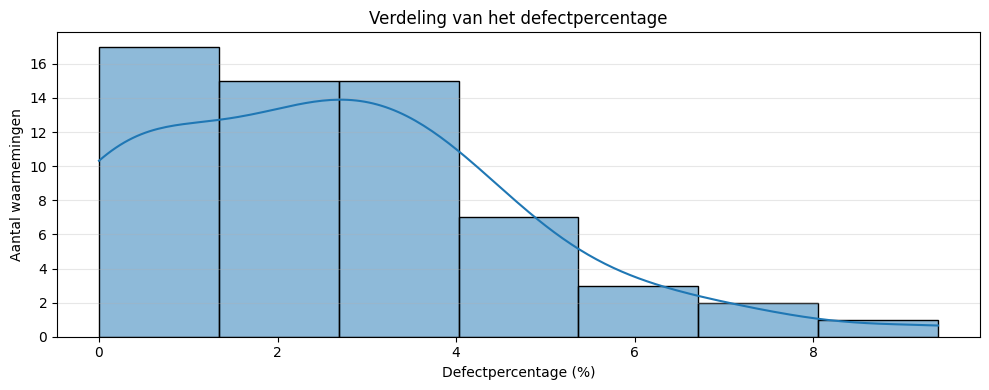

In [29]:
# Maak een histogram van het defectpercentage
plt.figure(figsize=(10, 4))
sns.histplot(model_df[target], kde=True)
plt.title("Verdeling van het defectpercentage")
plt.xlabel("Defectpercentage (%)")
plt.ylabel("Aantal waarnemingen")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

De histogram laat zien dat de meeste defectpercentages tussen 0% en 4% liggen. De verdeling loopt ongeveer van 0% tot 9,5% en heeft enkele hogere waarden aan de rechterkant. Het gemiddelde ligt rond 2,5%. Daarom kijken we naast het gemiddelde ook naar de spreiding en mogelijke uitschieters.

### 3.5 Verdeling van de features

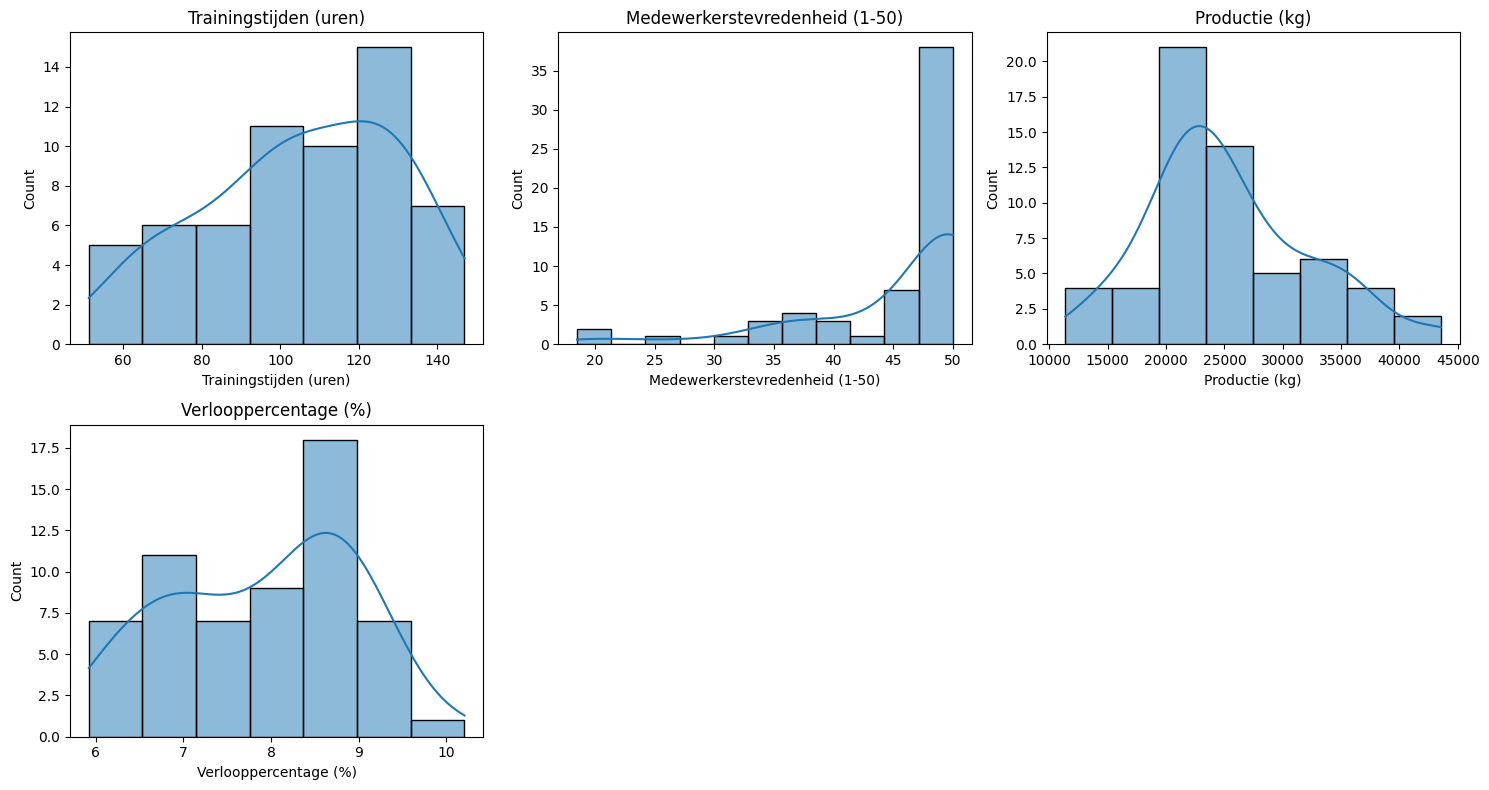

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, alle_features):
    sns.histplot(model_df[col], kde=True, ax=ax)
    ax.set_title(col)

# Verberg lege subplot
for ax in axes.flat[len(alle_features):]:
    ax.set_visible(False)

plt.tight_layout()

De features hebben verschillende schalen en spreidingen. Vooral medewerkerstevredenheid ligt vaak dicht bij de bovengrens van 50, terwijl trainingstijd en productie meer variatie tonen. Bij preprocessing moet daarom worden gecontroleerd of schalen en eventuele uitschieters invloed hebben op het model.

### 3.6 Outlierdetectie (IQR)

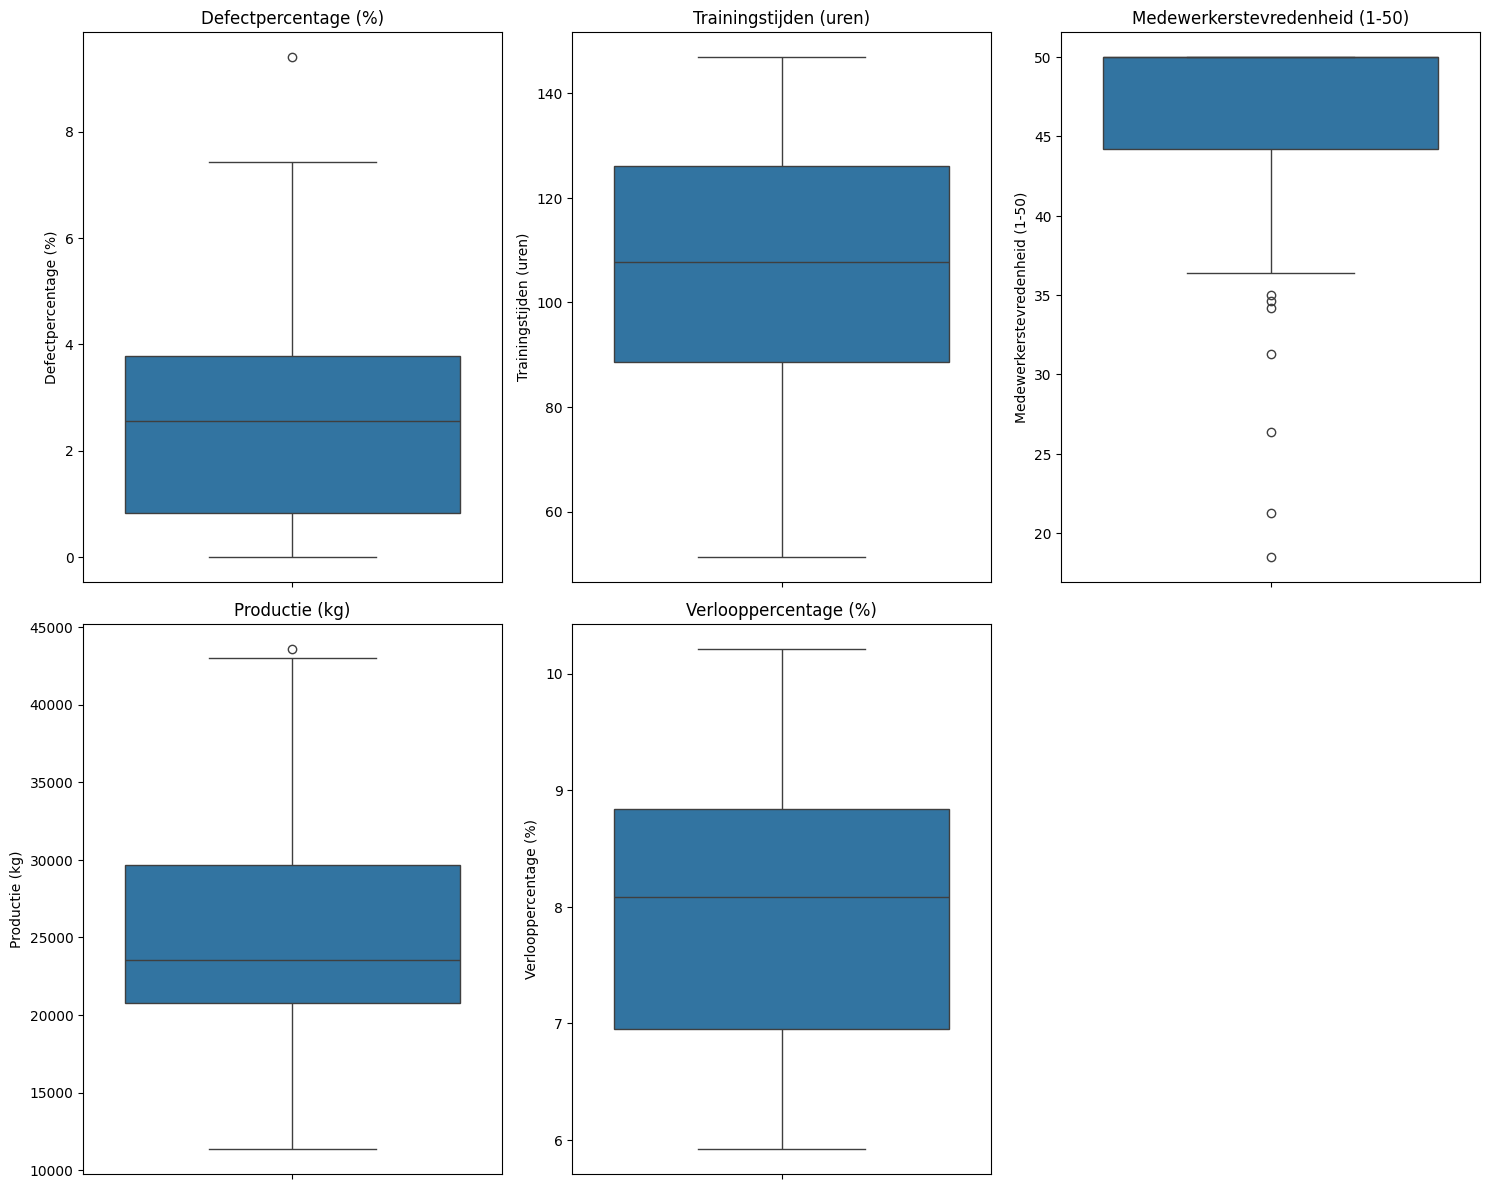

In [31]:
kolommen = [target] + alle_features

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, kolommen):
    sns.boxplot(y=model_df[col], ax=ax)
    ax.set_title(col)

for ax in axes.flat[len(kolommen):]:
    ax.axis("off")

plt.tight_layout()


In [32]:
for col in alle_features + [target]:
    q1, q3 = model_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    ondergrens, bovengrens = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((model_df[col] < ondergrens) | (model_df[col] > bovengrens)).sum()
    print(f"{col}: {n_outliers} outliers")


Trainingstijden (uren): 0 outliers
Medewerkerstevredenheid (1-50): 7 outliers
Productie (kg): 1 outliers
Verlooppercentage (%): 0 outliers
Defectpercentage (%): 1 outliers


De IQR-analyse laat zien dat trainingstijd en verlooppercentage geen uitschieters bevatten. Medewerkerstevredenheid heeft zeven uitschieters; productie en het defectpercentage hebben ieder één. Deze waarden worden niet direct verwijderd, omdat ze ook echte uitzonderlijke situaties kunnen weergeven.

### 3.7 Samenhang tussen features en target

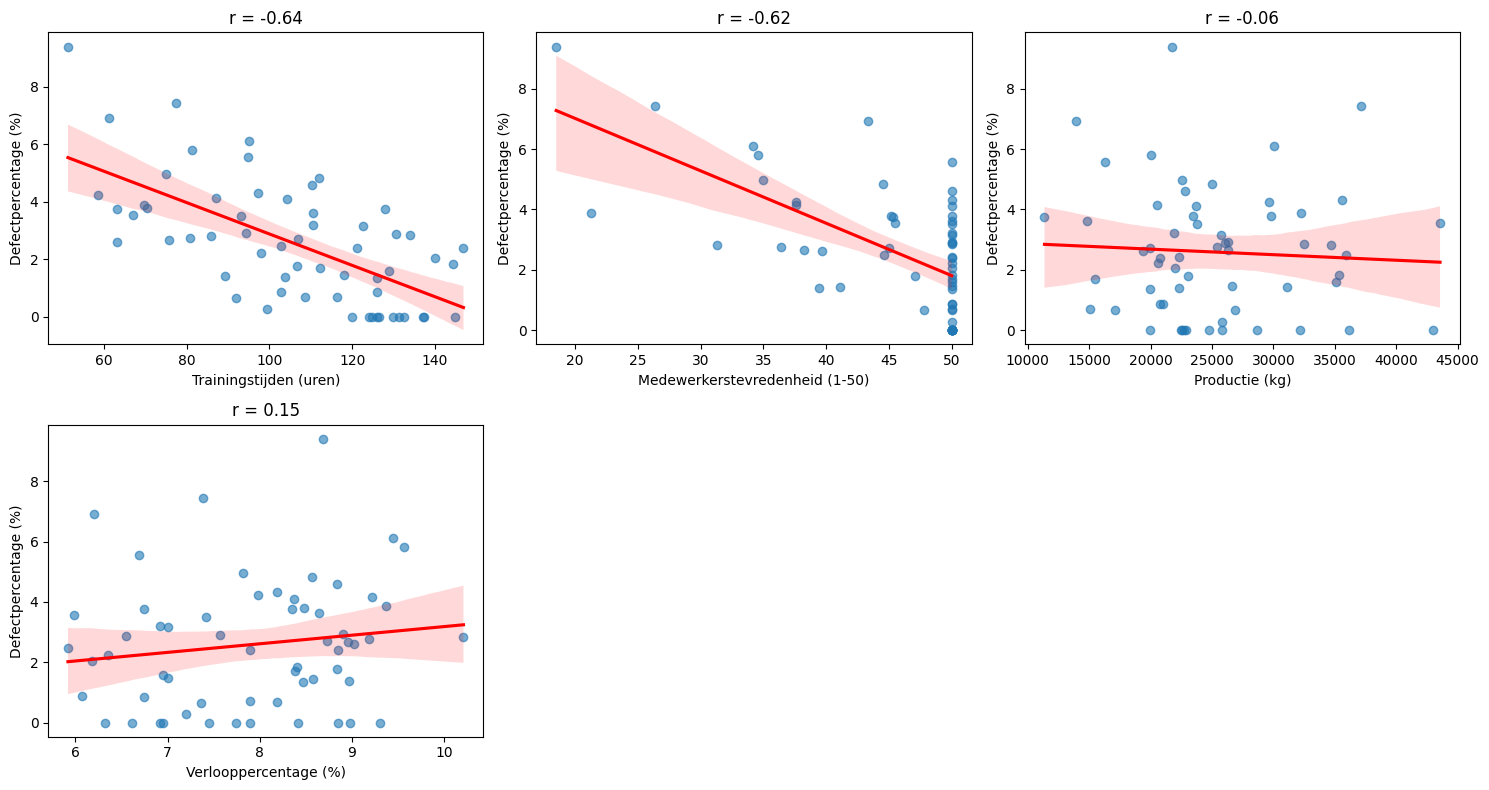

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, alle_features):
    sns.regplot(data=model_df, x=col, y=target, ax=ax,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
    for leeg_ax in axes.flat[len(alle_features):]:
        leeg_ax.set_visible(False)
    ax.set_title(f"r = {model_df[col].corr(model_df[target]):.2f}")
plt.tight_layout()

De regressieplots laten een duidelijk negatief lineair verband zien tussen trainingstijd, medewerkerstevredenheid en het defectpercentage. Voor productie en verlooppercentage is het verband veel zwakker. Deze variabelen kunnen toch relevant blijven wanneer er niet-lineaire verbanden of combinaties met andere features bestaan.

### 3.8 Correlatie tussen de features onderling

<Axes: >

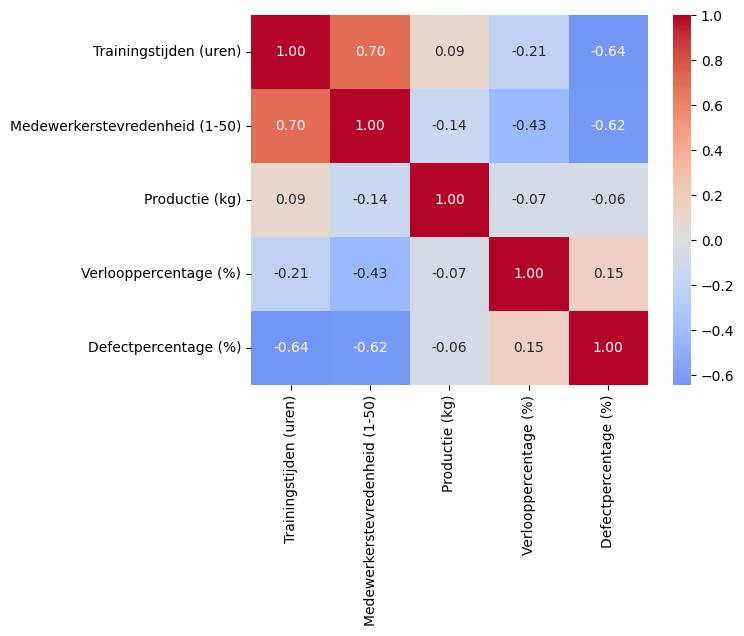

In [34]:
corr_matrix = model_df[alle_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")

De heatmap laat zien dat trainingstijd en medewerkerstevredenheid onderling sterk samenhangen (r = 0,70). Deze features bevatten daardoor deels vergelijkbare informatie. De overige verbanden tussen de features zijn beperkt, waardoor er weinig aanwijzingen zijn voor sterke multicollineariteit.

### 3.9 Tijdsreeks-patroon

Text(0.5, 1.0, 'Defectpercentage over tijd')

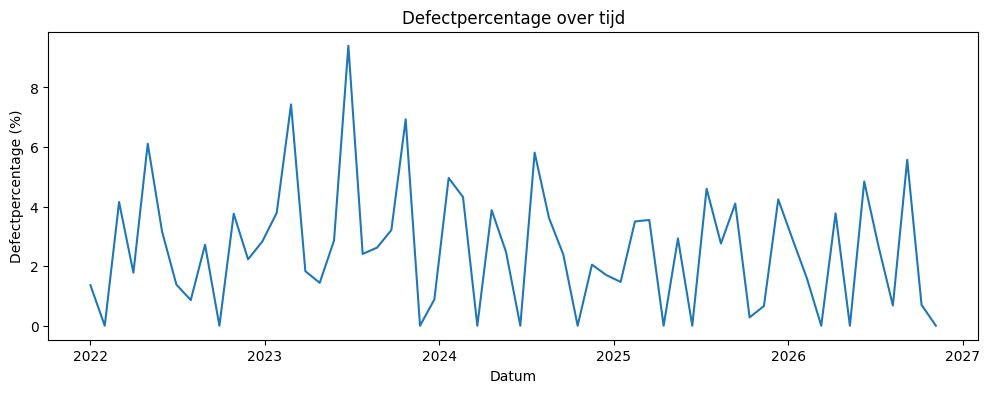

In [35]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=model_df, x="Datum", y=target)
plt.title("Defectpercentage over tijd")

Het defectpercentage wisselt sterk door de tijd en bevat meerdere pieken en dalen. Er is geen duidelijk terugkerend seizoenspatroon zichtbaar. Dit onderstreept de noodzaak van een model dat meerdere kenmerken tegelijk gebruikt om hoge defectpercentages te voorspellen.


### Interpretatie datakwaliteit

De EDA laat zien dat het defectpercentage sterk varieert: het gemiddelde ligt rond 2,5%, maar de waarden lopen uiteen van 0% tot 9,4%. In de tijd zijn meerdere pieken en dalen zichtbaar, zonder duidelijk terugkerend seizoenspatroon. Het is daarom relevant om het defectpercentage met meerdere kenmerken te voorspellen in plaats van alleen op tijdsperioden te vertrouwen.

Trainingstijd (r = -0,64) en medewerkerstevredenheid (r = -0,62) hebben het sterkste lineaire verband met het defectpercentage. Hogere waarden hangen samen met een lager defectpercentage, maar dit betekent niet automatisch dat er sprake is van een causaal verband. Productie en verlooppercentage hebben weinig lineaire correlatie, maar blijven inhoudelijk relevante aanvullende features. De kwaliteitsscore wordt niet gebruikt vanwege het risico op datalekken.

De outlieranalyse toont enkele uitschieters, vooral bij medewerkerstevredenheid. Deze worden niet vooraf verwijderd, omdat ze echte situaties kunnen vertegenwoordigen. Daarnaast hangen trainingstijd en medewerkerstevredenheid onderling sterk samen (r = 0,70), waardoor hiermee rekening moet worden gehouden bij de modellering. De definitieve featureset bestaat daarom uit trainingstijd, medewerkerstevredenheid, productie en verlooppercentage.

## 4. Data voorbereiden voor machine learning

Maak de dataset geschikt voor het trainen van een machine-learningmodel.

Welke stappen nodig zijn, hangt af van jullie probleem en dataset. Denk bijvoorbeeld aan:

- het oplossen van problemen die je hebt gevonden in je datakwaliteit onderzoek (zie lijstje daar)
- (extra) schalen of normaliseren;

- het selecteren van features en target;
- splitsen in train- en testdata.
- (extra) coderen van categorische variabelen;


Leg bij belangrijke stappen uit **waarom** jullie deze keuze maken.

### 4.1 Featuers en targets vastleggen


De features en target die in hoofdstuk 3 zijn geselecteerd, worden hier vastgelegd, zodat vanaf dit punt met een vaste X (features) en y (target) wordt gewerkt.



In [36]:
# Target en features voor het model definiëren
target = "Defectpercentage (%)"
alle_features = ["Trainingstijden (uren)", "Medewerkerstevredenheid (1-50)",
                  "Productie (kg)", "Verlooppercentage (%)"]

X = model_df[alle_features]
y = model_df[target]

print(X.shape, y.shape)
X.head()

(60, 4) (60,)


,Trainingstijden (uren),Medewerkerstevredenheid (1-50),Productie (kg),Verlooppercentage (%)
0,125.9,50.0,19943,8.47
1,129.9,50.0,22910,6.32
2,87.0,37.6,20558,9.22
3,106.6,47.1,23025,8.84
4,95.0,34.2,30066,9.45


Dezelfde features en target worden gebruikt die in hoofdstuk 3 zijn bepaald op basis van de correlatie- en EDA-analyse: Trainingstijden (uren), Medewerkerstevredenheid (1-50), Productie (kg) en Verlooppercentage (%) als features, en Defectpercentage (%) als target. De uitleg voor deze keuzes is in hoofdstuk 3 al uitgewerkt. Model_df wordt hergebruikt zodat de featureselectie consistent blijft met de eerdere analyse.



### 4.2 Splitsen in train- en testdata


De data wordt gesplitst in een trainingsset en een testset, zodat het model getraind kan worden op het ene deel en geëvalueerd kan worden op ongeziene data.



In [37]:
# Split de data in train- en testsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (48, 4), Test: (12, 4)


De data wordt gesplitst in een trainingsset (80%) en een testset (20%), wat neerkomt op 48 rijen om op te trainen en 12 rijen om het model te evalueren. Deze verhouding is gekozen omdat de dataset met 60 rijen relatief klein is: een groter testpercentage zou te weinig data overlaten om het model goed te trainen, terwijl een kleiner testpercentage te weinig data overlaat om de prestaties betrouwbaar te evalueren. Random_state=42 wordt vastgezet zodat de split reproduceerbaar is en dezelfde train/testverdeling ontstaat bij het opnieuw uitvoeren van het notebook.

### 4.3 Features schalen

De features worden geschaald met StandardScaler, zodat variabelen met grote absolute waarden niet zwaarder meewegen dan variabelen met kleine waarden puur door de schaal waar ze oorspronkelijk in staan.



In [38]:
# Schaal de features met StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=alle_features, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=alle_features, index=X_test.index
)

X_train_scaled.describe()


,Trainingstijden (uren),Medewerkerstevredenheid (1-50),Productie (kg),Verlooppercentage (%)
count,4.800000e+01,4.800000e+01,4.800000e+01,4.800000e+01
mean,-1.850372e-16,2.590520e-16,-1.850372e-16,-6.938894e-16
std,1.010582e+00,1.010582e+00,1.010582e+00,1.010582e+00
min,-2.161613e+00,-3.425574e+00,-1.994964e+00,-1.793373e+00
25%,-6.884358e-01,-3.177266e-01,-6.286640e-01,-8.811019e-01
50%,6.294364e-02,6.114235e-01,-3.459518e-01,1.452032e-01
75%,8.153091e-01,6.114235e-01,6.320990e-01,8.795814e-01
max,1.609089e+00,6.114235e-01,2.581875e+00,1.527294e+00


Uit de EDA (3.5) bleek dat de features sterk verschillende schalen hebben: Medewerkerstevredenheid ligt tussen 1 en 50, terwijl Trainingstijden en Productie (kg) veel grotere absolute waarden hebben. Zonder schaling zouden features met grote getallen (zoals Productie) zwaarder kunnen meewegen dan features met kleinere getallen. Daarom wordt StandardScaler toegepast, die elke feature herschaalt naar een gemiddelde van 0 en een standaarddeviatie van 1.

De scaler wordt alleen op de trainingsdata gefit, zodat deze niets "weet" van de testdata. Diezelfde scaler wordt vervolgens ook gebruikt om de testdata te herschalen, maar zonder er opnieuw op te fitten. Zo wordt voorkomen dat informatie uit de testset al wordt meegenomen in de training (datalekkage) en blijft de test een eerlijke simulatie van hoe het model presteert op nieuwe, ongeziene data.

Encoding van categorische variabelen is niet nodig, omdat alle gebruikte features numeriek zijn. Deze stap wordt daarom bewust overgeslagen.

### 4.4 Controle van de voorbereide data



De vorm en volledigheid van de train- en testset worden gecontroleerd, om te bevestigen dat de data klaar is voor modeltraining.

In [39]:
# Controleer of er nog ontbrekende waarden zijn na het schalen
print("Ontbrekende waarden in X_train:", X_train_scaled.isnull().sum().sum())
print("Ontbrekende waarden in X_test:", X_test_scaled.isnull().sum().sum())
print("Vorm train/test:", X_train_scaled.shape, X_test_scaled.shape)


Ontbrekende waarden in X_train: 0
Ontbrekende waarden in X_test: 0
Vorm train/test: (48, 4) (12, 4)


Als laatste stap wordt gecontroleerd of de voorbereide data klaar is voor modeltraining: er mogen geen ontbrekende waarden zijn ontstaan tijdens het splitsen of schalen en de vorm van train- en testset moet overeenkomen met de verwachte 80/20-verdeling. Deze controle bevestigt dat de data correct is voorbereid voordat in hoofdstuk 5 het model wordt getraind.

### 4.5 Toelichting op voorbereiding

Bij de voorbereiding van de data voor machine learning zijn een aantal belangrijke keuzes gemaakt, die hieronder worden samengevat.

Ten eerste zijn de features en de target niet opnieuw bepaald, maar overgenomen uit de correlatie- en EDA-analyse van hoofdstuk 3: Trainingstijden (uren), Medewerkerstevredenheid (1-50), Productie (kg) en Verlooppercentage (%) als features, met Defectpercentage (%) als target. Door hier consistent te blijven met de eerdere analyse, wordt voorkomen dat de featureselectie op twee verschillende momenten in het notebook uiteenloopt.

Ten tweede is de data gesplitst in een trainingsset (80%, 48 rijen) en een testset (20%, 12 rijen), met een vaste random_state=42 voor reproduceerbaarheid. Voor deze verhouding is gekozen omdat de dataset met 60 rijen relatief klein is: een groter testpercentage zou te weinig data overlaten om het model goed te trainen, terwijl een kleiner testpercentage te weinig data overlaat om de prestaties betrouwbaar te evalueren.

Ten derde zijn de features geschaald met StandardScaler, omdat uit de EDA (3.5) bleek dat de features sterk verschillende schalen hebben (bijvoorbeeld Medewerkerstevredenheid op een schaal van 1-50 tegenover Productie in de tienduizenden). Zonder schaling zouden features met grote absolute waarden zwaarder kunnen meewegen in het model, puur door hun schaal. De scaler is bewust alleen gefit op de trainingsdata en vervolgens toegepast op de testdata, om datalekkage te voorkomen en de testset een eerlijke simulatie van nieuwe, ongeziene data te laten blijven. Encoding van categorische variabelen was niet nodig, omdat alle gebruikte features al numeriek zijn.

Tot slot is gecontroleerd of de voorbereide data geen ontbrekende waarden bevat en of de vorm van de train- en testset overeenkomt met de verwachte 80/20-verdeling. Deze controle bevestigt dat de data correct en consistent is voorbereid, zodat in hoofdstuk 5 gestart kan worden met het trainen van het model.


## 5. Model trainen

Train een machine-learningmodel dat past bij jullie gekozen probleem.

Het model moet geschikt zijn voor óf:

- **regressie**: wanneer jullie een continue numerieke waarde voorspellen; of
- **classificatie**: wanneer jullie een categorie of klasse voorspellen.

Beschrijf in Markdown:

- welk model jullie gebruiken;
- waarom dit model geschikt is;
- welke inputvariabelen jullie gebruiken;
- hoe het model wordt getraind.

In [40]:
# Train hier jullie machine-learningmodel

# Definieer de drie modellen
modellen = {
    "Lineaire regressie": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=4, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42
    ),
}

# Train elk model op de geschaalde trainingsdata
for naam, model in modellen.items():
    model.fit(X_train_scaled, y_train)

print("Modellen getraind:", list(modellen.keys()))


Modellen getraind: ['Lineaire regressie', 'Random Forest', 'XGBoost']


### Toelichting op modelkeuze

Leg hier jullie keuze en aanpak uit.

## 6. Model evalueren

Evalueer hoe goed het model presteert met passende metrics.

Voorbeelden:

**Bij regressie:** bijvoorbeeld MAE, MSE, RMSE of R².

**Bij classificatie:** bijvoorbeeld accuracy, precision, recall, F1-score of een confusion matrix.

Kies metrics die passen bij jullie businessprobleem.

Leg uit:

- welke metrics jullie gebruiken;
- waarom deze metrics geschikt zijn;
- wat de uitkomsten betekenen;
- welke beperkingen het model heeft.

Een hoge score betekent niet automatisch dat een model bruikbaar is. Interpreteer de resultaten kritisch.

In [42]:
# Evalueer hier de prestaties van jullie model

# Evalueer alle modellen met dezelfde metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

resultaten = []

for naam, model in modellen.items():
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    resultaten.append({"Model": naam, "MAE": mae, "RMSE": rmse, "R2": r2})

resultaten_df = pd.DataFrame(resultaten).set_index("Model")
resultaten_df


,MAE,RMSE,R2
Model,,,
Lineaire regressie,1.283592,1.612482,-0.132405
Random Forest,1.676632,1.871809,-0.525931
XGBoost,1.864286,2.031081,-0.796662


### Interpretatie van de modelevaluatie

Schrijf hier wat de resultaten betekenen en welke beperkingen jullie zien.

## 7. Vertaling naar de businesscase

Ga terug naar het oorspronkelijke businessprobleem.

Beschrijf:

- wat de modelresultaten betekenen voor de organisatie;
- hoe het model in de praktijk gebruikt zou kunnen worden;
- welke beslissingen je wel en niet op basis van dit model zou kunnen nemen;
- welke risico's en beperkingen er zijn;
- wat een logische volgende stap zou zijn.

Maak duidelijk onderscheid tussen:

- wat het model daadwerkelijk laat zien;
- wat jullie daaruit concluderen;
- welk businessadvies jullie op basis daarvan geven.

### Businessimplicaties en conclusie

Schrijf hier jullie conclusie en advies.

## 8. Controle vóór inleveren

Controleer vóór het inleveren:

- [ ] Namen en studentennummers van alle groepsleden staan in het notebook.
- [ ] Het businessprobleem en de keuze voor regressie of classificatie zijn duidelijk.
- [ ] De dataset is ingeladen en onderzocht.
- [ ] Datakwaliteit is onderzocht met code én visualisaties.
- [ ] Belangrijke keuzes worden uitgelegd in Markdown.
- [ ] Het model is getraind.
- [ ] Het model is met passende metrics geëvalueerd.
- [ ] De resultaten zijn vertaald naar implicaties voor de businesscase.
- [ ] Het notebook is van boven naar beneden opnieuw uitgevoerd.
- [ ] Alles ook werkt in iemands ander omgeving (bijv. dataset inladen)
- [ ] Alle cellen werken zonder fouten.
- [ ] Alle relevante output en visualisaties zijn zichtbaar.
- [ ] Er afdoende duidelijk geschreven toelichting staat.
- [ ] Het pythonnotebook een duidelijke naam heeft, bijv. met je groepje erin.

> Een notebook dat niet uitvoerbaar is, is niet ontvankelijk.